# NLP: Classification supervisée de produits e-commerce
## De l'etude de faisabilité au MVP (Minimum Viable Product)

In [22]:
## Imports et ocnfiguration
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

## Imports Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix)
from sklearn.preprocessing import LabelEncoder
from src.models.ml_pipeline import MLPipeline
from src.models.evaluator import ModelEvaluator, robust_cv_evaluation
import xgboost as xgb

# Configuration reproductible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [23]:

# Configuration des hyperparamètres
CONFIGS = {
    'logistic_regression': {
        'model': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'description': 'Régression logistique avec régularisation L2'
    },
    'random_forest': {
        'model': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
        'description': 'Random Forest - Bon pour capturer les interactions complexes'
    },
    'svm_rbf': {
        'model': SVC(kernel='rbf', random_state=RANDOM_STATE, probability=True),
        'description': 'SVM avec noyau RBF - Efficace pour l\'espace haute dimension'
    },
    'xgboost': {
        'model': xgb.XGBClassifier(random_state=RANDOM_STATE, enable_categorical=True, eval_metric='mlogloss'),
        'description': 'XGBoost - Gradient boosting performant'
    }
}

In [24]:
#Initialisation
pipeline = MLPipeline(random_state=RANDOM_STATE)

In [25]:
# Chargment des données
df = pipeline.load_processed_data('ecommerce_data_processed.csv')

Données chargées : 1050 produits, 23 variables


## Division des données

In [26]:
print("\n Division stratifiée des données")
print("-"*40)
X_train, X_val, X_test, y_train, y_val, y_test = pipeline.create_stratified_split(
    df, 'description_clean_stem', 'target'
)



 Division stratifiée des données
----------------------------------------
Division des données :
Train: 630 (60.0%)
Validation: 210 (20.0%)
Test: 210 (20.0%)

Distribution des classes :
   Train: {'Computers': 0.143, 'HomeDecorFestiveNeeds': 0.143, 'BabyCare': 0.143, 'KitchenDining': 0.143, 'HomeFurnishing': 0.143, 'Watches': 0.143, 'BeautyandPersonalCare': 0.143}
   Val: {'HomeDecorFestiveNeeds': 0.143, 'BabyCare': 0.143, 'Watches': 0.143, 'Computers': 0.143, 'BeautyandPersonalCare': 0.143, 'HomeFurnishing': 0.143, 'KitchenDining': 0.143}
   Test: {'Computers': 0.143, 'HomeFurnishing': 0.143, 'Watches': 0.143, 'HomeDecorFestiveNeeds': 0.143, 'KitchenDining': 0.143, 'BabyCare': 0.143, 'BeautyandPersonalCare': 0.143}


## Préparation des features

In [27]:
X_train_vec, X_val_vec, X_test_vec = pipeline.prepare_features(
    X_train, X_val, X_test, method='tfidf'
)


Préparation des features - Méthode: tfidf
Vocabulaire: 3375 mots
Matrice train: (630, 3375)
Densité: 1.0000


## Modèles baselines

In [28]:
evaluator = ModelEvaluator()

In [29]:
# Créer l'encodeur
le = LabelEncoder()

# Important : Fit sur TOUTES les données
all_labels = pd.concat([y_train, y_val, y_test])
le.fit(all_labels)

# Encoder
y_train_encoded = le.transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

# Sauvegarder les noms des classes
class_names = le.classes_

print(f"Encodage fait : {dict(zip(class_names, range(len(class_names))))}")

Encodage fait : {'BabyCare': 0, 'BeautyandPersonalCare': 1, 'Computers': 2, 'HomeDecorFestiveNeeds': 3, 'HomeFurnishing': 4, 'KitchenDining': 5, 'Watches': 6}


In [30]:
# Entraînement de tous les modèles
for model_name, config in CONFIGS.items():
    print(f"\n{config['description']}")
    model = config['model']
    evaluator.train_and_evaluate(model, X_train_vec, X_val_vec, y_train_encoded, y_val_encoded, model_name)


Régression logistique avec régularisation L2

 Entraînement logistic_regression
Accuracy: 0.9190
Temps entraînement: 0.08s
Temps prédiction: 0.00s

Random Forest - Bon pour capturer les interactions complexes

 Entraînement random_forest
Accuracy: 0.9190
Temps entraînement: 0.11s
Temps prédiction: 0.04s

SVM avec noyau RBF - Efficace pour l'espace haute dimension

 Entraînement svm_rbf
Accuracy: 0.9238
Temps entraînement: 0.52s
Temps prédiction: 0.04s

XGBoost - Gradient boosting performant

 Entraînement xgboost
Accuracy: 0.9048
Temps entraînement: 0.67s
Temps prédiction: 0.00s


In [31]:
# Comparaison des résultats
comparison_df, best_model = evaluator.compare_models()


 COMPARAISON DES MODÈLES
             Modèle Accuracy F1 Macro F1 Weighted Temps Train (s) Temps Pred (s)
logistic_regression   0.9190   0.9191      0.9191            0.08         0.0004
      random_forest   0.9190   0.9192      0.9192            0.11         0.0420
            svm_rbf   0.9238   0.9253      0.9253            0.52         0.0423
            xgboost   0.9048   0.9050      0.9050            0.67         0.0027

 Meilleur modèle (F1 weighted): svm_rbf
   Performance: 0.9253


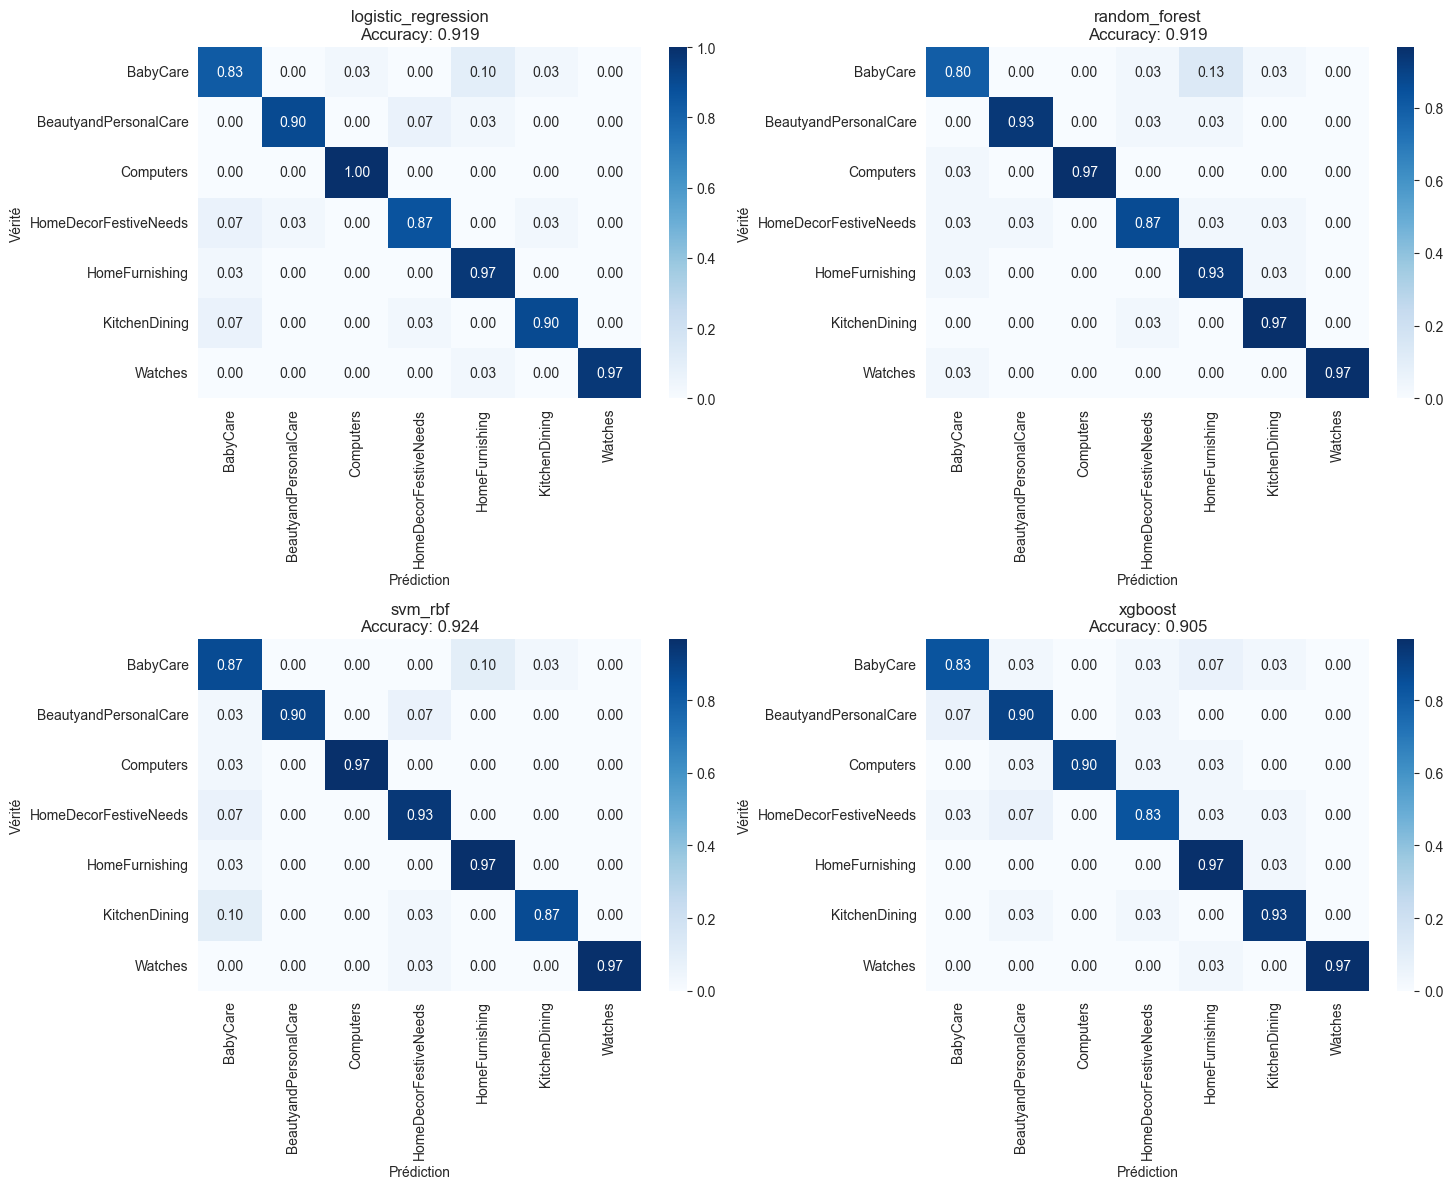

In [32]:
# Affichage des matrices de confusion
class_names = sorted(df['target'].unique())
evaluator.plot_confusion_matrices(class_names)

## Validation croisée stratifiée pour le meilleur modèle des baselines

In [33]:
# Récupération du meilleur modèle
best_model_obj = evaluator.results[best_model]['model']

In [34]:
# Combinaison train + validation pour la validation croisée
from scipy.sparse import vstack
X_train_val = vstack([X_train_vec, X_val_vec])
y_train_val = pd.concat([y_train, y_val])

In [35]:

print(f"Modèle sélectionné : {best_model}")
print(f"Données pour CV : {X_train_val.shape[0]} échantillons")

Modèle sélectionné : svm_rbf
Données pour CV : 840 échantillons


In [36]:
# Validation croisée
cv_stats = robust_cv_evaluation(best_model_obj, X_train_val, y_train_val, cv=5)


 Validation croisée stratifiée (5 folds)
   Fold 1/5... F1: 0.911
   Fold 2/5... F1: 0.926
   Fold 3/5... F1: 0.942
   Fold 4/5... F1: 0.929
   Fold 5/5... F1: 0.976


In [37]:
# Affichage des résultats
print(f"\nRÉSULTATS DE LA VALIDATION CROISÉE")
print("-" * 50)
for metric, stats in cv_stats.items():
    print(f"{metric.upper()}:")
    print(f"   Moyenne: {stats['mean']:.4f} ± {stats['std']:.4f}")
    print(f"   IC 95%: [{stats['ci_lower']:.4f}, {stats['ci_upper']:.4f}]")

# Analyse de la stabilité
print(f"\n ANALYSE DE LA STABILITÉ")
print("-" * 30)
f1_variance = cv_stats['f1_weighted']['std']
f1_mean = cv_stats['f1_weighted']['mean']
stability_ratio = f1_variance / f1_mean

if stability_ratio < 0.05:
    stability = "Très stable"
elif stability_ratio < 0.1:
    stability = "Stable"
else:
    stability = "Instable"

print(f"Coefficient de variation F1: {stability_ratio:.4f}")
print(f"Évaluation de la stabilité: {stability}")


RÉSULTATS DE LA VALIDATION CROISÉE
--------------------------------------------------
ACCURACY:
   Moyenne: 0.9369 ± 0.0218
   IC 95%: [0.9066, 0.9672]
PRECISION_MACRO:
   Moyenne: 0.9411 ± 0.0211
   IC 95%: [0.9118, 0.9703]
RECALL_MACRO:
   Moyenne: 0.9369 ± 0.0218
   IC 95%: [0.9066, 0.9672]
F1_MACRO:
   Moyenne: 0.9367 ± 0.0220
   IC 95%: [0.9062, 0.9672]
F1_WEIGHTED:
   Moyenne: 0.9367 ± 0.0220
   IC 95%: [0.9062, 0.9672]

 ANALYSE DE LA STABILITÉ
------------------------------
Coefficient de variation F1: 0.0235
Évaluation de la stabilité: Très stable
